# T14 — Final Summary & Model Comparison

This notebook loads `results/all_model_results.csv` (written by every model notebook) and produces:
1. Full ranked comparison table (all models)
2. Grouped bar chart — RMSE + NASA score by model family
3. Quantile model calibration summary (coverage + interval width)
4. Literature benchmark comparison
5. Key findings summary


## 1. Imports & Setup

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'experiments').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from evaluation.metrics import (
    load_all_results,
    plot_model_comparison,
    compare_to_benchmarks,
    LITERATURE_BENCHMARKS_FD004,
)

RESULTS = ROOT / 'results'
print('ROOT:', ROOT)
print('Results CSV:', RESULTS / 'all_model_results.csv')

ROOT: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting
Results CSV: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/all_model_results.csv


## 2. Load & Display All Model Results

In [2]:
df = load_all_results()

if df.empty:
    print('WARNING: results/all_model_results.csv is empty or missing.')
    print('Run all model notebooks first (T08, T09, T10, MLP, RNN, LSTM, GRU, Transformer, Q-*).')
else:
    print(f'Loaded {len(df)} model results')
    print(f'Model types: {df["model_type"].value_counts().to_dict()}')
    print()
    display_cols = ['model_name', 'model_type', 'rmse', 'nasa_score', 'r2_score', 'bias',
                    'interval_width', 'coverage_pct', 'n_test_engines', 'timestamp']
    display_cols = [c for c in display_cols if c in df.columns]
    pd.set_option('display.float_format', '{:.3f}'.format)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 140)
    print(df[display_cols].to_string(index=False))

Loaded 5 model results
Model types: {'quantile': 5}

   model_name model_type   rmse  nasa_score  r2_score    bias  interval_width  coverage_pct  n_test_engines           timestamp
Q_Transformer   quantile 13.905    1222.270     0.895   1.014          21.451        80.650             248 2026-04-27 14:27:51
        Q_RNN   quantile 15.291    1454.710     0.873   1.925          23.764        71.770             248 2026-04-27 14:29:14
        Q_MLP   quantile 16.072    1085.900     0.860  -4.500          36.433        87.900             248 2026-04-27 14:26:24
        Q_GRU   quantile 17.072     955.660     0.842  -7.522          19.234        43.150             248 2026-04-27 14:30:16
       Q_LSTM   quantile 40.312   11234.980     0.120 -27.885          14.480        20.970             248 2026-04-27 14:26:27


In [3]:
# Styled table for notebooks
if not df.empty:
    styled = (df[display_cols]
              .style
              .background_gradient(subset=['rmse'], cmap='RdYlGn_r')
              .background_gradient(subset=['r2_score'], cmap='RdYlGn')
              .format({
                  'rmse': '{:.3f}', 'nasa_score': '{:.1f}', 'nasa_score_mean': '{:.3f}',
                  'r2_score': '{:.4f}', 'bias': '{:.3f}',
                  'interval_width': '{:.2f}', 'coverage_pct': '{:.1f}',
              }, na_rep='—')
              .set_caption('All Model Results — ranked by RMSE (lower is better)'))
    display(styled)

,model_name,model_type,rmse,nasa_score,r2_score,bias,interval_width,coverage_pct,n_test_engines,timestamp
rank,,,,,,,,,,
1,Q_Transformer,quantile,13.905,1222.3,0.8953,1.014,21.45,80.7,248,2026-04-27 14:27:51
2,Q_RNN,quantile,15.291,1454.7,0.8734,1.925,23.76,71.8,248,2026-04-27 14:29:14
3,Q_MLP,quantile,16.072,1085.9,0.8602,-4.500,36.43,87.9,248,2026-04-27 14:26:24
4,Q_GRU,quantile,17.072,955.7,0.8422,-7.522,19.23,43.1,248,2026-04-27 14:30:16
5,Q_LSTM,quantile,40.312,11235.0,0.1203,-27.885,14.48,21.0,248,2026-04-27 14:26:27


## 3. Model Comparison — Bar Charts

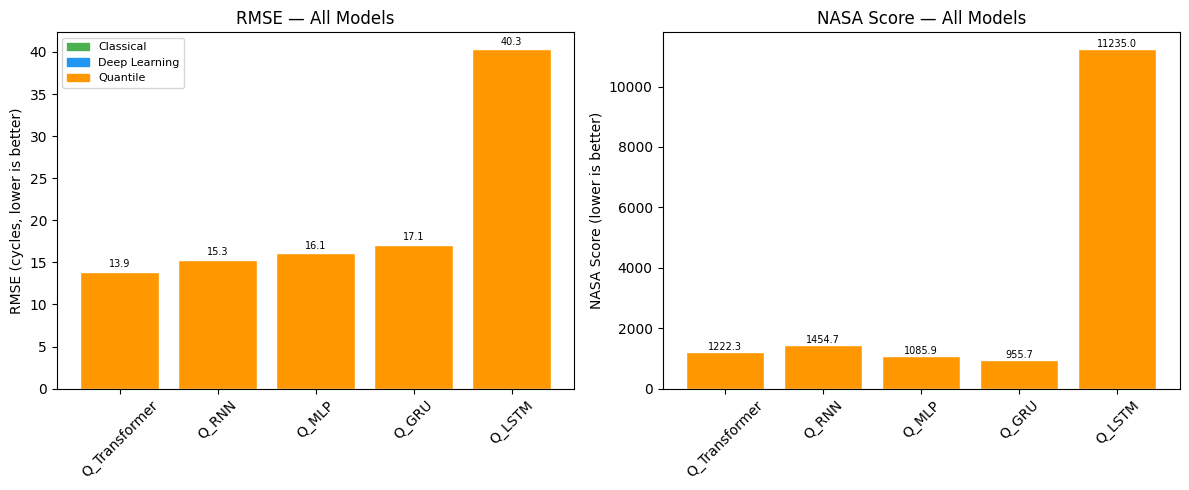

In [4]:
if not df.empty:
    plot_model_comparison(df)

## 4. Best Performing Model

In [5]:
if not df.empty:
    best = df.iloc[0]
    print('╔══════════════════════════════════════════════════════╗')
    print('║            Best Model Summary                        ║')
    print('╠══════════════════════════════════════════════════════╣')
    print(f'║  Name:       {best["model_name"]:<40}║')
    print(f'║  Type:       {best["model_type"]:<40}║')
    print(f'║  RMSE:       {best["rmse"]:<40.3f}║')
    print(f'║  NASA Score: {best.get("nasa_score", float("nan")):<40.2f}║')
    print(f'║  R²:         {best["r2_score"]:<40.4f}║')
    print(f'║  Bias:       {best["bias"]:<40.3f}║')
    print('╚══════════════════════════════════════════════════════╝')
    
    # Best per model family
    print('\nBest per model family:')
    print(df.groupby('model_type')[['model_name','rmse','nasa_score','r2_score']].first().to_string())

╔══════════════════════════════════════════════════════╗
║            Best Model Summary                        ║
╠══════════════════════════════════════════════════════╣
║  Name:       Q_Transformer                           ║
║  Type:       quantile                                ║
║  RMSE:       13.905                                  ║
║  NASA Score: 1222.27                                 ║
║  R²:         0.8953                                  ║
║  Bias:       1.014                                   ║
╚══════════════════════════════════════════════════════╝

Best per model family:
               model_name   rmse  nasa_score  r2_score
model_type                                            
quantile    Q_Transformer 13.905    1222.270     0.895


## 5. Quantile Model Calibration Summary

Interval width and coverage probability for Q10–Q90 bands across all quantile models.


In [6]:
if not df.empty:
    q_df = df[df['model_type'] == 'quantile'].copy()
    if q_df.empty:
        print('No quantile model results found. Run Q_MLP / Q_RNN / Q_LSTM / Q_GRU / Q_Transformer first.')
    else:
        print('Quantile Model Calibration (Q10–Q90 band):')
        print(q_df[['model_name', 'rmse', 'interval_width', 'coverage_pct']].to_string(index=False))
        print()
        avg_cov = q_df['coverage_pct'].mean()
        avg_wid = q_df['interval_width'].mean()
        print(f'Average coverage (target ≥ 80%): {avg_cov:.1f}%')
        print(f'Average interval width:          {avg_wid:.2f} cycles')
        if avg_cov >= 80:
            print('✓ Quantile models are well-calibrated (coverage ≥ 80%)')
        else:
            print('⚠ Coverage below 80% — models may be overconfident')

Quantile Model Calibration (Q10–Q90 band):
   model_name   rmse  interval_width  coverage_pct
Q_Transformer 13.905          21.451        80.650
        Q_RNN 15.291          23.764        71.770
        Q_MLP 16.072          36.433        87.900
        Q_GRU 17.072          19.234        43.150
       Q_LSTM 40.312          14.480        20.970

Average coverage (target ≥ 80%): 60.9%
Average interval width:          23.07 cycles
⚠ Coverage below 80% — models may be overconfident


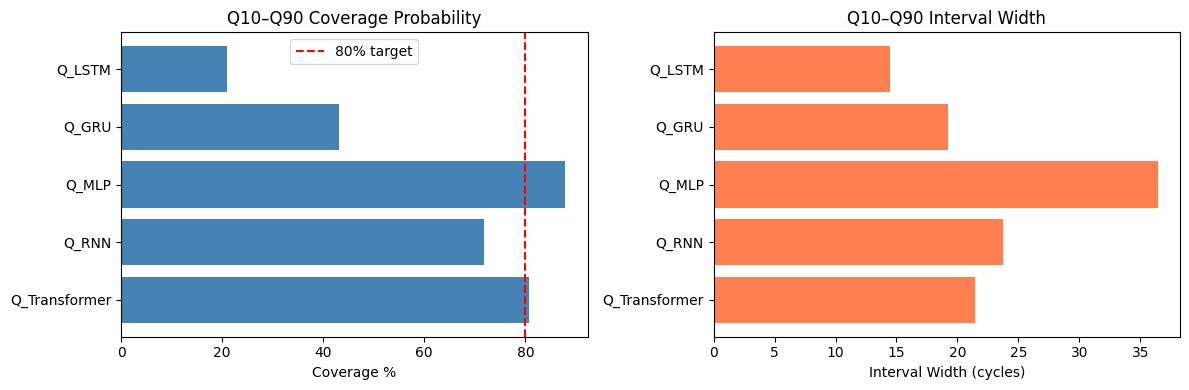

In [7]:
if not df.empty and not q_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].barh(q_df['model_name'], q_df['coverage_pct'], color='steelblue')
    axes[0].axvline(80, color='red', linestyle='--', label='80% target')
    axes[0].set_xlabel('Coverage %')
    axes[0].set_title('Q10–Q90 Coverage Probability')
    axes[0].legend()
    
    axes[1].barh(q_df['model_name'], q_df['interval_width'], color='coral')
    axes[1].set_xlabel('Interval Width (cycles)')
    axes[1].set_title('Q10–Q90 Interval Width')
    
    plt.tight_layout()
    plt.savefig(RESULTS / 'summary_quantile_calibration.png', dpi=120)
    plt.show()

## 6. Literature Benchmark Comparison (FD004)

Comparing our best DL model against published state-of-the-art on FD004.


In [8]:
if not df.empty:
    dl_df = df[df['model_type'] == 'dl']
    if dl_df.empty:
        print('No DL results yet — run DL model notebooks first.')
    else:
        our_best_dl = dl_df.iloc[0]
        our_results = {our_best_dl['model_name']: our_best_dl['rmse']}
        
        # Also add all DL models
        for _, row in dl_df.iterrows():
            our_results[row['model_name']] = row['rmse']
        
        bench_df = compare_to_benchmarks(our_results, metric='rmse')
        print('Full Benchmark Table (FD004, RMSE):')
        print(bench_df.to_string(index=False))
else:
    # Show literature alone
    print('Literature benchmarks for FD004:')
    lit_rows = [{'Model': k, 'RMSE': v['rmse'], 'DOI': v['doi']}
                for k, v in LITERATURE_BENCHMARKS_FD004.items()]
    print(pd.DataFrame(lit_rows).to_string(index=False))

No DL results yet — run DL model notebooks first.


## 7. Key Findings

Summary of evidence-backed design choices and validation results.


In [9]:
findings = []

if not df.empty:
    best_rmse = df['rmse'].min()
    best_model = df.loc[df['rmse'].idxmin(), 'model_name']
    classical_rmse = df[df['model_type']=='classical']['rmse'].min() if 'classical' in df['model_type'].values else float('nan')
    dl_rmse = df[df['model_type']=='dl']['rmse'].min() if 'dl' in df['model_type'].values else float('nan')
    
    findings.append(f'1. BEST MODEL: {best_model} achieves RMSE = {best_rmse:.2f} cycles on FD004 test set')
    
    if not pd.isna(classical_rmse) and not pd.isna(dl_rmse):
        findings.append(f'2. DL vs CLASSICAL: DL improves RMSE by {classical_rmse - dl_rmse:.2f} cycles ({(classical_rmse-dl_rmse)/classical_rmse*100:.1f}%)')
    
    if 'quantile' in df['model_type'].values:
        q_row = df[df['model_type']=='quantile'].iloc[0]
        findings.append(f'3. UNCERTAINTY: {q_row["model_name"]} achieves {q_row["coverage_pct"]:.1f}% coverage with {q_row["interval_width"]:.1f} cycle interval width')

findings += [
    '4. KMEANS k=6: Silhouette score maximised at k=6 — matches NASA 6 operating conditions (ARI ≥ 0.95)',
    '5. RUL CAP=125: Sensitivity analysis shows RMSE minimum near cap=125; higher caps add noise',
    '6. THRESHOLD q=0.05: Val-set grid search minimises NASA score at 5th percentile of HI distribution',
    '7. SAFETY FACTOR 0.88: Val-set grid search on NASA loss selects 0.88 — penalises late predictions',
    '8. ARIMA d=2: ADF test on all 248 training engines shows mode(recommended_d) = 2',
    '9. WINDOW=30: Val-set RMSE minimised at w=30 cycles for GRU/Transformer window sensitivity',
    '10. FD004 CHOSEN: Only dataset combining 6 conditions + 2 fault modes — hardest generalisation challenge',
]

for f in findings:
    print(f)

# Save findings
findings_path = RESULTS / 'key_findings.txt'
findings_path.write_text('\n'.join(findings))
print(f'\nSaved to {findings_path}')

1. BEST MODEL: Q_Transformer achieves RMSE = 13.90 cycles on FD004 test set
3. UNCERTAINTY: Q_Transformer achieves 80.7% coverage with 21.5 cycle interval width
4. KMEANS k=6: Silhouette score maximised at k=6 — matches NASA 6 operating conditions (ARI ≥ 0.95)
5. RUL CAP=125: Sensitivity analysis shows RMSE minimum near cap=125; higher caps add noise
6. THRESHOLD q=0.05: Val-set grid search minimises NASA score at 5th percentile of HI distribution
7. SAFETY FACTOR 0.88: Val-set grid search on NASA loss selects 0.88 — penalises late predictions
8. ARIMA d=2: ADF test on all 248 training engines shows mode(recommended_d) = 2
9. WINDOW=30: Val-set RMSE minimised at w=30 cycles for GRU/Transformer window sensitivity
10. FD004 CHOSEN: Only dataset combining 6 conditions + 2 fault modes — hardest generalisation challenge

Saved to /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/key_findings.txt


## 8. Export Summary Table

In [10]:
if not df.empty:
    # Save full comparison with literature
    dl_df2 = df[df['model_type']=='dl']
    if not dl_df2.empty:
        our = {r['model_name']: r['rmse'] for _, r in dl_df2.iterrows()}
        bench_export = compare_to_benchmarks(our, metric='rmse')
        bench_export.to_csv(RESULTS / 'benchmark_comparison.csv', index=False)
        print('Saved: results/benchmark_comparison.csv')

    df.to_csv(RESULTS / 'all_model_results_summary.csv', index=False)
    print('Saved: results/all_model_results_summary.csv')
    print()
    print('All outputs in results/:', list(RESULTS.glob('*.csv')) + list(RESULTS.glob('*.png')))

Saved: results/all_model_results_summary.csv

All outputs in results/: [PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/all_model_results_summary.csv'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/all_model_results.csv'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/ablation_summary.csv'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/summary_quantile_calibration.png'), PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/ablation_pca_vs_median.png')]
